In [ ]:
!pip install unidecode


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 17.8 MB/s eta 0:00:00


In [ ]:
import requests
import zipfile
import os
import urllib3

# Tắt cảnh báo SSL
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# URLs
train_url = 'https://rrc.cvc.uab.es/downloads/ch4_training_word_images_gt.zip'
test_url = 'https://rrc.cvc.uab.es/downloads/ch4_test_word_images_gt.zip'

data_dir = './icdar2015'
os.makedirs(data_dir, exist_ok=True)

def download_and_unzip_requests(url, save_path):
    os.makedirs(save_path, exist_ok=True)  # <-- Tạo thư mục nếu chưa tồn tại
    local_zip_path = os.path.join(save_path, 'temp.zip')

    print(f"Downloading from {url}...")
    with requests.get(url, verify=False, stream=True) as r:
        r.raise_for_status()
        with open(local_zip_path, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)

    print(f"Extracting to {save_path}...")
    with zipfile.ZipFile(local_zip_path, 'r') as zip_ref:
        zip_ref.extractall(save_path)

    os.remove(local_zip_path)  # Xóa file zip tạm
    print("Done!")

# Tải dữ liệu
download_and_unzip_requests(train_url, os.path.join(data_dir, 'train'))
download_and_unzip_requests(test_url, os.path.join(data_dir, 'test'))
import os
from sklearn.model_selection import train_test_split

root_dir = './icdar2015/train'
gt_file = os.path.join(root_dir, 'gt.txt')

samples = []
with open(gt_file, 'r', encoding='utf-8-sig') as f:
    for line in f:
        parts = line.strip().split(',')
        img_name, label = parts[0], ','.join(parts[1:])
        samples.append((img_name, label))

# Chia 80% train, 20% test
train_samples, test_samples = train_test_split(samples, test_size=0.2, random_state=42)

# Lưu ra file mới
with open(os.path.join(root_dir, 'train_split.txt'), 'w', encoding='utf-8') as f:
    for img, lbl in train_samples:
        f.write(f"{img},{lbl}\n")

with open(os.path.join(root_dir, 'test_split.txt'), 'w', encoding='utf-8') as f:
    for img, lbl in test_samples:
        f.write(f"{img},{lbl}\n")


Extracting to ./icdar2015/train...
Done!
Extracting to ./icdar2015/test...
Done!


In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import os
from unidecode import unidecode

class ICDAR2015WordDataset(Dataset):
    def __init__(self, txt_file, img_dir, transform=None):
        self.img_labels = []
        with open(txt_file, 'r', encoding='utf-8') as f:
          for line in f:
              img, label = line.strip().split(',', 1)
              label = label.strip().strip('"')  # loại bỏ dấu ngoặc kép
              self.img_labels.append((img, label))
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_name, label = self.img_labels[idx]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label
from torchvision import transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),   # Khớp input ResNet
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # Giống khi train ResNet
                         std=[0.229, 0.224, 0.225])
])

train_dataset = ICDAR2015WordDataset('./icdar2015/train/train_split.txt', './icdar2015/train', transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
import torchvision.models as models
import torch.nn as nn

class ResNetBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet18(pretrained=True)
        self.cnn = nn.Sequential(*list(resnet.children())[:-2])  # B, 512, 7, 7

    def forward(self, x):
        features = self.cnn(x)                  # [B, 512, H/32, W/32] ≈ [B, 512, 7, 7]
        B, C, H, W = features.size()
        features = features.permute(0, 2, 3, 1) # → [B, H, W, C]
        features = features.reshape(B, -1, C)   # → [B, T, C], với T = H × W
        return features
class SimpleTokenizer:
    def __init__(self, chars="abcdefghijklmnopqrstuvwxyz0123456789", pad='<PAD>', sos='<SOS>', eos='<EOS>'):
        self.chars = list(chars)
        self.specials = [pad, sos, eos]
        self.vocab = self.specials + self.chars
        self.stoi = {s: i for i, s in enumerate(self.vocab)}
        self.itos = {i: s for s, i in self.stoi.items()}

    def encode(self, text, max_len):
        tokens = [self.stoi['<SOS>']] + [self.stoi[c] for c in unidecode(text.lower()) if c in self.stoi] + [self.stoi['<EOS>']]
        tokens += [self.stoi['<PAD>']] * (max_len - len(tokens))
        return tokens[:max_len]

    def decode(self, indices):
        tokens = []
        for i in indices:
            token = self.itos.get(i, '')
            if token == '<EOS>': break
            if token not in self.specials:
                tokens.append(token)
        return ''.join(tokens)

    @property
    def vocab_size(self):
        return len(self.vocab)
import torch
import torch.nn as nn

class OCRDecoder(nn.Module):
    def __init__(self, vocab_size, d_model=512, nhead=8, num_layers=3, max_len=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_embed = nn.Parameter(torch.randn(1, max_len, d_model))
        self.layers = nn.ModuleList([
            nn.TransformerDecoderLayer(d_model, nhead) for _ in range(num_layers)
        ])
        self.fc = nn.Linear(d_model, vocab_size)
        self.max_len = max_len
        self.d_model = d_model

    def forward(self, tgt, memory, return_attn=False):
        tgt_embed = self.embedding(tgt) * (self.d_model ** 0.5)
        tgt_embed += self.pos_embed[:, :tgt.size(1)]
        tgt_embed = tgt_embed.permute(1, 0, 2)  # [T, B, C]
        memory = memory.permute(1, 0, 2)        # [S, B, C]

        tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt_embed.size(0)).to(tgt.device)

        attn_weights = []

        output = tgt_embed
        for layer in self.layers:
            output = layer(output, memory, tgt_mask=tgt_mask)
            if return_attn:
                # Không dễ lấy attention trực tiếp nếu không custom
                # Vì PyTorch không return weights by default
                pass  # placeholder nếu muốn custom

        output = output.permute(1, 0, 2)        # [B, T, C]
        logits = self.fc(output)                # [B, T, vocab_size]
        return logits

class OCRModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.encoder = ResNetBackbone()
        self.decoder = OCRDecoder(vocab_size)

    def forward(self, images, tgt_seq):
        features = self.encoder(images)           # [B, S, C]
        output = self.decoder(tgt_seq, features)  # [B, T, vocab_size]
        return output
import torch.nn.functional as F

def train_batch(model, images, labels, tokenizer, device):
    model.train()
    images, labels = images.to(device), labels.to(device)
    outputs = model(images, labels[:, :-1])  # input: no <EOS>, output: predict next
    loss = F.cross_entropy(outputs.reshape(-1, tokenizer.vocab_size),
                           labels[:, 1:].reshape(-1), ignore_index=tokenizer.stoi['<PAD>'])
    return loss
def predict(model, image, tokenizer, device, max_len=32):
    model.eval()
    image = image.unsqueeze(0).to(device)
    memory = model.encoder(image)  # [1, S, C]
    tgt = torch.tensor([[tokenizer.stoi['<SOS>']]], device=device)

    for _ in range(max_len):
        out = model.decoder(tgt, memory)  # [1, T, vocab_size]
        next_token = out[:, -1, :].argmax(dim=-1, keepdim=True)  # [1, 1]
        tgt = torch.cat([tgt, next_token], dim=1)
        if next_token.item() == tokenizer.stoi['<EOS>']:
            break

    return tokenizer.decode(tgt[0].tolist())


In [ ]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torch

# Reuse ICDAR2015WordDataset đã có ở trên
# Tokenizer như ở bước trước
tokenizer = SimpleTokenizer()
MAX_LEN = 32  # tối đa chiều dài chuỗi đầu ra (gồm <SOS> và <EOS>)

def collate_fn(batch):
    images, texts = zip(*batch)
    images = torch.stack(images)  # KHÔNG gọi transform nữa
    labels = torch.tensor([tokenizer.encode(t, MAX_LEN) for t in texts])
    return images, labels


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_dataset = ICDAR2015WordDataset('./icdar2015/train/train_split.txt', './icdar2015/train', transform)
test_dataset = ICDAR2015WordDataset('./icdar2015/train/test_split.txt', './icdar2015/train', transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = OCRModel(vocab_size=tokenizer.vocab_size).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
import torch.nn.functional as F

def train_one_epoch(model, dataloader, optimizer, tokenizer, device):
    model.train()
    total_loss = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images, labels[:, :-1])  # Predict next tokens
        loss = F.cross_entropy(
            outputs.reshape(-1, tokenizer.vocab_size),
            labels[:, 1:].reshape(-1),
            ignore_index=tokenizer.stoi['<PAD>']
        )

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(dataloader)
def evaluate(model, dataloader, tokenizer, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            for i in range(images.size(0)):
                pred = predict(model, images[i], tokenizer, device)
                target = tokenizer.decode(labels[i].tolist())
                if pred.strip().lower() == target.strip().lower():
                    correct += 1
                total += 1

    return correct / total
EPOCHS = 15
best_acc = 0.0

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, tokenizer, device)
    val_acc = evaluate(model, test_loader, tokenizer, device)

    print(f"[Epoch {epoch+1}] Loss: {train_loss:.4f} | Val Acc: {val_acc*100:.2f}%")

    # 🔽 Lưu mô hình nếu tốt hơn
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'best_ocr_model.pth')
        print(f"✅ Saved new best model at epoch {epoch+1} with Val Acc: {val_acc*100:.2f}%")



[Epoch 1] Loss: 2.5701 | Val Acc: 4.92%
✅ Saved new best model at epoch 1 with Val Acc: 4.92%
[Epoch 2] Loss: 2.0257 | Val Acc: 9.17%
✅ Saved new best model at epoch 2 with Val Acc: 9.17%
[Epoch 3] Loss: 1.5728 | Val Acc: 12.75%
✅ Saved new best model at epoch 3 with Val Acc: 12.75%
[Epoch 4] Loss: 1.1676 | Val Acc: 17.34%
✅ Saved new best model at epoch 4 with Val Acc: 17.34%
[Epoch 5] Loss: 0.8213 | Val Acc: 17.79%
✅ Saved new best model at epoch 5 with Val Acc: 17.79%
[Epoch 6] Loss: 0.5864 | Val Acc: 19.80%
✅ Saved new best model at epoch 6 with Val Acc: 19.80%
[Epoch 7] Loss: 0.4376 | Val Acc: 20.58%
✅ Saved new best model at epoch 7 with Val Acc: 20.58%
[Epoch 8] Loss: 0.3417 | Val Acc: 22.60%
✅ Saved new best model at epoch 8 with Val Acc: 22.60%
[Epoch 9] Loss: 0.2606 | Val Acc: 22.71%
✅ Saved new best model at epoch 9 with Val Acc: 22.71%
[Epoch 10] Loss: 0.2161 | Val Acc: 23.71%
✅ Saved new best model at epoch 10 with Val Acc: 23.71%
[Epoch 11] Loss: 0.1869 | Val Acc: 24.61%


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def show_predictions(model, dataloader, tokenizer, device, n=5):
    model.eval()
    count = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            for i in range(images.size(0)):
                image = images[i]
                pred_text = predict(model, image, tokenizer, device)
                true_text = tokenizer.decode(labels[i].tolist())

                # Chuyển tensor ảnh về ảnh hiển thị
                img_np = image.cpu().permute(1, 2, 0).numpy()
                img_np = (img_np * 0.5) + 0.5  # unnormalize do Normalize([0.5])
                img_np = np.clip(img_np, 0, 1)

                # Hiển thị ảnh + text
                plt.figure(figsize=(4, 3))
                plt.imshow(img_np)
                plt.axis('off')
                plt.title(f"GT: {true_text}\nPred: {pred_text}", fontsize=10)
                plt.tight_layout()
                plt.show()

                count += 1
                if count >= n:
                    return


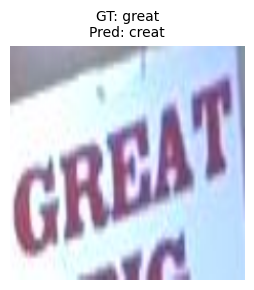

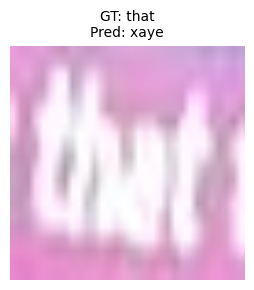

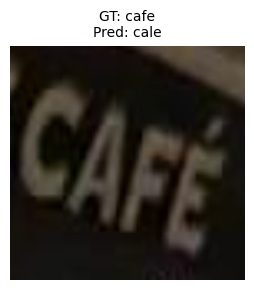

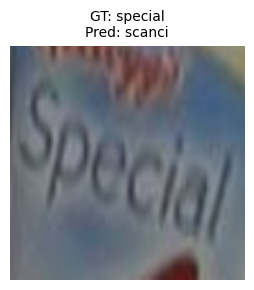

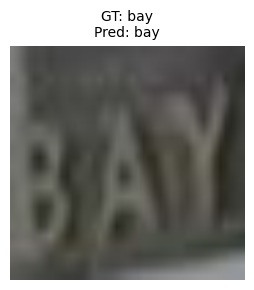

In [ ]:
show_predictions(model, test_loader, tokenizer, device, n=5)
